In [ ]:
# Descriptive Stats 
import numpy as np
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

In [63]:
# System and OS related tasks
import sys
import os
import importlib
# Add the project root to Python path
project_root = os.path.abspath('..')
sys.path.insert(0, project_root)

# path to directories
raw_dir = '../data/raw'
processed_dir = '../data/processed'

In [64]:
# Read in the Top Tea producing countries with GDP and Climate zone
filename = "df_main_tea_gdp_climate.csv"


df_main_tea_gdp_climate = pd.read_csv(
    f"{processed_dir}/{filename}",
    header=0,
    )
df_main_tea_gdp_climate.head(3)

,Country_ISO3,Year,Area_Harvest_Ha,Production_Ton,Yield_Kg_Ha,Crop_Type,Country_Name,GDP_Per_Capita,Temperature,Precipitation,Crop_Dominance,GDP_Level,Climate_Zone
0,ARG,2000,38620.0,323000.0,8363.5,Tea,Argentina,7637.014892,14.45,721.03,tea only,High GDP,Cool
1,ARG,2001,37420.0,309000.0,8257.6,Tea,Argentina,7141.475077,15.08,716.55,tea only,High GDP,Cool
2,ARG,2002,36400.0,306000.0,8406.6,Tea,Argentina,2569.699635,14.84,757.75,tea only,High GDP,Cool


# 1.0 Linear Regression on Temperature and Precipitation

📌 The `df_main_tea_gdp_climate` has many columns (such as `Country_ISO3`, `Country_Name`, `Climate_Zone`) that we do not need. It also has columns like `Area_Harvested` that are used to derived our target variable `Yield_Kg_Ha` which we do not need.  

📌 As we have seen so far, we know that `Temperature` is a relevant feature as we have seen in Hypothesis 1. We have also seen in Hypothesis 2 that the nominal `GDP_Per_Capita` has no impact on Yield within each year. So for this model, we will only look at `Temperature` and `Precipitation`.

👨🏻‍💻 This is a simple dataset for a simple model to demonstate the whole supervised learning process.

In [78]:
want_col_list = ["Temperature", "Precipitation", "Yield_Kg_Ha"]

df_model = df_main_tea_gdp_climate.copy()

df_model = df_model[want_col_list]

df_model.head(3)

,Temperature,Precipitation,Yield_Kg_Ha
0,14.45,721.03,8363.5
1,15.08,716.55,8257.6
2,14.84,757.75,8406.6


## 1.1 Split Data Into Training and Testing

📌 Split the data for modelling into test and training datasets

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
                                    df_model.drop(['Yield_Kg_Ha'], axis=1), # for the X dependent variables& dropping the target variable
                                    df_model['Yield_Kg_Ha'],# add the target valurable
                                    test_size=0.2,
                                    random_state=101  # set the seed for the random generator for the splitting process
                                    )

print(
    "* Train set:",
    X_train.shape,
    y_train.shape,
    "\n* Test set:",
    X_test.shape,
    y_test.shape,
)

* Train set: (300, 2) (300,) 
* Test set: (75, 2) (75,)


📌 Re-confirm that there are no missing values:

In [67]:
print(df_model.isnull().sum())

Temperature      0
Precipitation    0
Yield_Kg_Ha      0
dtype: int64


---

## 1.2 Build the Pipeline

📌  The `StandardScaler` is used so that features like Temperature with double digit values will not be overwhelmed by features such as GDP with large values.

📌  We will rely on the feature selector `Lasso` as it can automatically select featires that are useful by setting unused features' coefficient to zero. As we have only 3 features to play with, we will set `alpha` to be very small to keep as many features as necessary.

In [68]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel

def pipeline_linear_regression():
    """
    Create a pipeline for linear regression.

    This function creates a pipeline that performs feature scaling, feature selection,
    and linear regression modeling.

    Returns:
        pipeline (Pipeline): The pipeline object that performs the specified steps.
    """
    pipeline = Pipeline([
        ("feat_scaler", StandardScaler()),
        ("feat_selector", SelectFromModel(Lasso(alpha=0.01))),  # Lasso automatically selects
        ("model", LinearRegression())
    ])
    return pipeline

pipeline_linear_regression()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feat_scaler', ...), ('feat_selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.",Lasso(alpha=0.01)
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",None
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1


---

## 1.3 Teach the Machine for the Fitting

📌 Ask the model to fit on the training data.

In [69]:
pipeline = pipeline_linear_regression()
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feat_scaler', ...), ('feat_selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.",Lasso(alpha=0.01)
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",None
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1


In [70]:
def linear_model_coefficients(model, columns):
    """
    Print the intercept and coefficients of a linear model.

    Parameters:
    model (object): The trained linear model object.
    columns (array-like): The column names corresponding to the coefficients.

    Returns:
    None
    """
    print(f"* Interception: {model.intercept_}")
    coeff_df = pd.DataFrame(model.coef_, columns, columns=["Coefficient"]).sort_values(
        ["Coefficient"], key=abs, ascending=False
    )
    print("* Coefficients")
    print(coeff_df)

In [71]:
pipeline['model']

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [72]:
pipeline['feat_selector'].get_support()

array([ True,  True])

📌 Looks like both the features have been kept by the `lasso` selector. 

In [73]:
X_train.columns[pipeline['feat_selector'].get_support()]

Index(['Temperature', 'Precipitation'], dtype='str')

📌 Get the coefficients of `Temperature` and `Precipitation`.

In [74]:
linear_model_coefficients(
    model=pipeline['model'],
    columns=X_train.columns[pipeline['feat_selector'].get_support()])

* Interception: 7956.683666666667
* Coefficients
               Coefficient
Precipitation  -973.099003
Temperature     221.907526


📌 The linear regression model is:

>
>`Tea Yield` (Kg/Ha) = 7956.68 + (221.91 × `Temperature`) + (-973.10 × `Precipitation`)
>

📌🔍🕵🏻‍♂️ What the linear regression model is saying:
* when temperature and precipitation is zero, the yield is 7,957 Kg/Ha.
  * In reality, this does not make any sense as tea plants cannot survive at 0<sup>°</sup>C.
* the temperature is positively related to the yield. For every 1<sup>°</sup>C increase, the tea yield would increase by 222 Kg/Ha.
  * In reality, perhaps this only make sense to a certain degree. We cannot simply increase tea yield by hoping for an even hotter temperature! There will be a certain temperature that the tea plants would be scorched.
* the precipitation is negatively related to the yield such that for every 1mm per year of reduction in precipitation then the yield would decrease by 973 Kg/Ha. 
  * Similarly, we cannot simply increase tea yield by hoping for lower precipitation as the tea plants would need water to survive nor can it survive in a desert environment!

---

## 1.4 Evaluate the Model

In [75]:
# import regression metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error 
# we will use numpy to calculate RMSE based on MSE (mean_squared_error)
import numpy as np


def regression_performance(X_train, y_train, X_test, y_test, pipeline):
    """
    Gets train/test sets and pipeline and evaluates the performance
    for each set (train and test) by calling regression_evaluation()
    which will evaluate the pipeline performance.
    is called by regression_evaluation(X, y, pipeline) as defined below

    Parameters:
    - X_train: The input features of the training set.
    - y_train: The target values of the training set.
    - X_test: The input features of the test set.
    - y_test: The target values of the test set.
    - pipeline: The regression pipeline to evaluate.

    Returns:
    None
    """

    print("Model Evaluation \n")
    print("* Train Set")
    regression_evaluation(X_train, y_train, pipeline)
    print("* Test Set")
    regression_evaluation(X_test, y_test, pipeline)


def regression_evaluation(X, y, pipeline):
    """
    Gets features and target (either from train or test set) and pipeline.
    
    Args:
        X (array-like): The input features.
        y (array-like): The target values.
        pipeline (object): The trained pipeline for regression.
    
    Returns:
        None
    
    Prints the following performance metrics comparing the prediction to the target:
    - R² (R-Squared) Score: How much variance is explained by the model? 0.6 = 60% of house price variation can be explained by the features
    - Mean Absolute Error
    - Mean Squared Error
    - Root Mean Squared Error
    """
    prediction = pipeline.predict(X)
    print("R2 Score:", round(r2_score(y, prediction),3))
    print("Mean Absolute Error:", round(mean_absolute_error(y, prediction),3))
    print("Mean Squared Error:", round(mean_squared_error(y, prediction),3))
    print(
        "Root Mean Squared Error:", round(np.sqrt(mean_squared_error(y, prediction)),3)
    )
    print("\n")

  

def regression_evaluation_plots(X_train, y_train, X_test, y_test, pipeline, alpha_scatter=0.5):
    """
    Gets Train and Test set (features and target), pipeline, and adjusts dots transparency
    at scatter plot.

    Parameters:
    - X_train (array-like): Training set features.
    - y_train (array-like): Training set target.
    - X_test (array-like): Test set features.
    - y_test (array-like): Test set target.
    - pipeline (object): Trained regression pipeline.
    - alpha_scatter (float, optional): Transparency level for scatter plot dots. Default is 0.5.

    Returns:
    None

    Functionality:
    - Predicts on the train and test set using the provided pipeline.
    - Creates Actual vs Prediction scatterplots for the train and test set.
    - Draws a red diagonal line. In theory, a good regressor should predict
        close to the actual, meaning the dot should be close to the diagonal red line.
        The closer the dots are to the line, the better.
    - Displays the scatterplots.
    """

# the pipeline defined above inherit the .predict() method from sklearn.pipeline.pipeline
    pred_train = pipeline.predict(X_train)  # Get predictions for training data
    pred_test = pipeline.predict(X_test)    # Get predictions for testing data

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    # plot the training data
    sns.scatterplot(x=y_train, y=pred_train, alpha=alpha_scatter, ax=axes[0])
    sns.lineplot(x=y_train, y=y_train, color="red", ax=axes[0])
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predictions")
    axes[0].set_title("Train Set")

    # plot the testing data
    sns.scatterplot(x=y_test, y=pred_test, alpha=alpha_scatter, ax=axes[1])
    sns.lineplot(x=y_test, y=y_test, color="red", ax=axes[1])
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predictions")
    axes[1].set_title("Test Set")

    plt.show()

📌 Now, evaluate the model:

Model Evaluation 

* Train Set
R2 Score: 0.086
Mean Absolute Error: 2081.853
Mean Squared Error: 8086312.439
Root Mean Squared Error: 2843.644


* Test Set
R2 Score: 0.08
Mean Absolute Error: 1885.962
Mean Squared Error: 7188237.578
Root Mean Squared Error: 2681.089




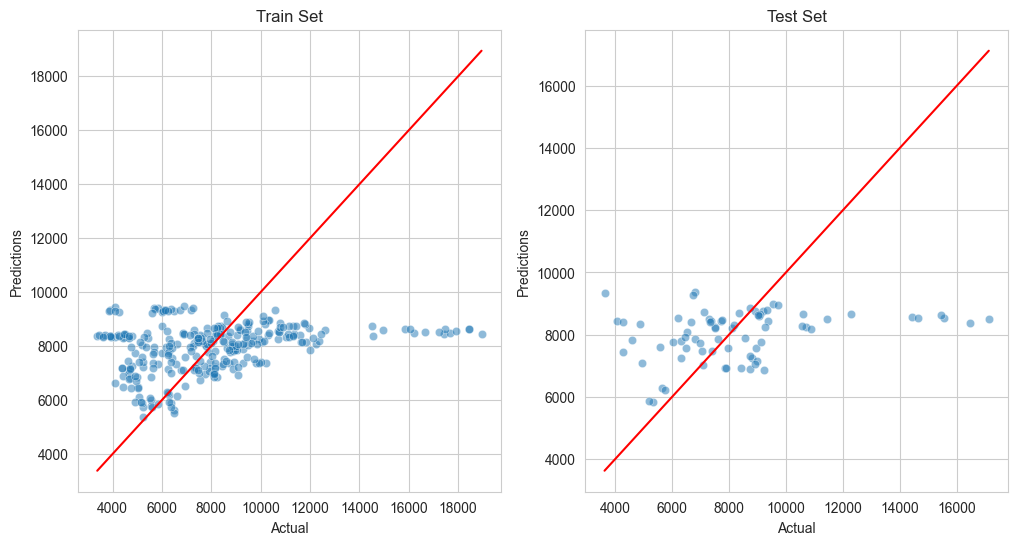

In [76]:
# 1. Get numerical metrics
regression_performance(X_train, y_train, X_test, y_test, pipeline)

# 2. Get visual diagnostics
regression_evaluation_plots(
    X_train, y_train, X_test, y_test, pipeline, alpha_scatter=0.5
)

📌🔍🕵🏻‍♂️ Model Evaluation:
* The plots of this linear regression do appear to fit both the training and test data well. 
* Using only a climate related model to predict Tea Yield, we achieved a R<sup>2</sup> values of only 0.086 and 0.08 on the Training set and on the Test data respectively. The model only explain 8% (a small portion) of the yield variation. 
* The MAE of 2082 kg/ha is a unsubstantial error in prediction. 
* This suggest that clearly, other factors must also (soil quality, altitude, agricultural practices, plant cultivars etc) affect tea yields as climate alone can only do so much to predict it.

---

# 2.0 Linear Regression on Climate and GDP

It is already mentioned in Hypothesis 2 that:
* Nominal `GDP_Per_Capita` cannot and should not be used to compare across year.
* That across the 25 years, the nominal GDP per capita data used in this project has statistically insigificant effect on the tea yield.

However, for the sake of completeness, we can attempt to a linear regression on the climate and GDP.

In [90]:
want_col_list = ["Temperature", "Precipitation", "GDP_Per_Capita", "Yield_Kg_Ha"]

df_model2 = df_main_tea_gdp_climate.copy()

df_model2 = df_model2[want_col_list]

df_model2.head(3)

,Temperature,Precipitation,GDP_Per_Capita,Yield_Kg_Ha
0,14.45,721.03,7637.014892,8363.5
1,15.08,716.55,7141.475077,8257.6
2,14.84,757.75,2569.699635,8406.6


## 2.1 Split Data Into Training and Testing

In [91]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
                                    df_model2.drop(['Yield_Kg_Ha'], axis=1), # for the X dependent variables& dropping the target variable
                                    df_model2['Yield_Kg_Ha'],# add the target valurable
                                    test_size=0.2,
                                    random_state=101  # set the seed for the random generator for the splitting process
                                    )

print(
    "* Train set 2:",
    X2_train.shape,
    y2_train.shape,
    "\n* Test set 2:",
    X2_test.shape,
    y2_test.shape,
)

* Train set 2: (300, 3) (300,) 
* Test set 2: (75, 3) (75,)


## 1.2 Teach the Machine for the Fitting

In [92]:
pipeline2 = pipeline_linear_regression()
pipeline2.fit(X2_train, y2_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feat_scaler', ...), ('feat_selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.",Lasso(alpha=0.01)
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",None
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1


In [93]:
pipeline2['model']

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [94]:
pipeline2['feat_selector'].get_support()

array([ True,  True,  True])

📌 Interestingly, the `lasso` has actually kept the `GDP_Per_Capita` feature!

In [95]:
X2_train.columns[pipeline2['feat_selector'].get_support()]

Index(['Temperature', 'Precipitation', 'GDP_Per_Capita'], dtype='str')

In [96]:
linear_model_coefficients(
    model=pipeline2['model'],
    columns=X2_train.columns[pipeline2['feat_selector'].get_support()])

* Interception: 7956.683666666667
* Coefficients
                Coefficient
Precipitation  -1351.454758
Temperature      934.950766
GDP_Per_Capita   928.510466


📌 The linear regression model is:

>
>`Tea Yield` (Kg/Ha) = 7956.68 + (934.95 × `Temperature`) + (-1351.45 × `Precipitation`) + (928.51 x `GDP_Per_Capita`)
>

📌🔍🕵🏻‍♂️ What this second linear regression model is saying:
* when temperature and precipitation is zero, the yield is 7,957 Kg/Ha.
  * We mentioned earlier that in reality, this does not make any sense.
* the temperature is positively related to the yield. For every 1<sup>°</sup>C increase, the tea yield would increase by 934 Kg/Ha.
  * We mentioned earlier that in reality, perhaps this only make sense to a certain degree.
* the precipitation is negatively related to the yield such that for every 1mm per year of reduction in precipitation then the yield would decrease by 1,351 Kg/Ha. 
  * Similarly, we cannot simply increase tea yield by hoping for lower precipitation.

📌🔍🕵🏻‍♂️ Also note that, interestingly the y-intercept for both models are the _**exact same value**_ of `7956.683666666667`. This intercept value is the predicted yield when all scaled features are at their mean = 0.
  * This can be interpreted as the GDP_Per_Capital not having an impact in the model at all even though Lasso method did not exclude GDP in model 2 but the algorithm has deemed GDP to be important enough to keep it by exagerating the impact of temperature and precipitation (much larger coefficients) in order to achieve a higher R<sup>2</sup>.
  * We know that nominal GDP per capita cannot be used to compare across years yet the lasso algorithm included it in the model for the sake of better prediction capabilities. This is therefor a question of using our understanding of the data rather then blindly pursuing models with higher prediction powers. 

## 1.3 Evaluate the Model

Model Evaluation 

* Train Set
R2 Score: 0.143
Mean Absolute Error: 1981.335
Mean Squared Error: 7582108.316
Root Mean Squared Error: 2753.563


* Test Set
R2 Score: 0.12
Mean Absolute Error: 1686.511
Mean Squared Error: 6874645.419
Root Mean Squared Error: 2621.955




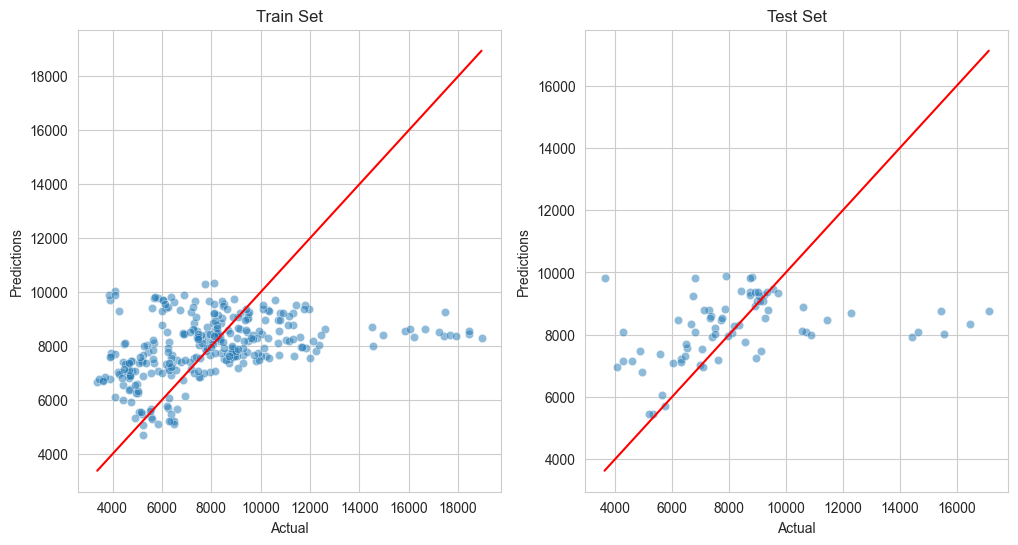

In [97]:
# 1. Get numerical metrics
regression_performance(X2_train, y2_train, X2_test, y2_test, pipeline2)

# 2. Get visual diagnostics
regression_evaluation_plots(
    X2_train, y2_train, X2_test, y2_test, pipeline2, alpha_scatter=0.5
)

📌🔍🕵🏻‍♂️ Model Evaluation:
* The plots of this linear regression do  appear to fit both the training and test data well. 
* Using only a climate + GDP related model to predict Tea Yield, we achieved an even better R<sup>2</sup> values of only 0.143 and 0.12 on the Training set and on the Test data respectively. Still, the model only explain 14.4% (still a small portion) of the yield variation compared to the 8% by the climate only model.
* The MAE of 1982 kg/ha is lesser than the climate only model but it is still a not unsubstantial error in prediction. 

📌🔍🕵🏻‍♂️ Now, the mystery of both model having the same intercept can perhaps be explained here:
* the Lasso imposed a penalty for bad features. If it includes a bad feature that the model prediction rates declines. 
* the alpha set for lasso is very small at 0.01 which means the keeping the GDP is worth it. Why is it worth it?
    * with the GDP, the model has a higher R<sup>2</sup> then the model without. 
    * as such, the model with the GDP is actually to _**"cover up"**_ how badly the climatel only model is doing. Since to the Lasso method, it is worth keeping the GDP to improved the model prediction.
    * this can be seen in the reduction of the coefficients of both the Temperature and Precipitation after GDP has been removed from the model.

📌🔍🕵🏻‍♂️ While it is interesting to learn how Lasso works in this project, it is in important lesson to learn about the interaction between data and machine learning.
* We know that nominal GDP_Per_Capita should not be used in comparing (or predicting) accross years due to exchange rate and inflation effects. Even when confined to within-year comparisons, Hyothesis 2 showed no significant relationship between GDP and tea yield.
* However, when included in a linear regression model with the temperature and precipitation, GDP receied a non-zero coefficinet of 928 (when Lasso should exclude it by setting it to 0) and improved the R<sup>2</sup> from 0/08 to 0.14. Thus, at first glance, this might suggest that nominmal GDP might matter after all. 
* Without the GDP in the model, the coefficient of Temperature and Precipitation both dropped a large margin. This simply suggests that Lasso (with the aim of increasing the prediction score of R<sup2</sup>>) has decided to include GDP inorder to "exagerate" the impact of climate so as to attain a higher prediction thereby masking the weakess of climate in predicting yield. This is probably, by chance, that the GDP data is correlated to the climate data.
* This is an important lesson to learn. Machine learning algorithms are optimise for prediction and not causal understanding. A feature can improved a model's prediction purely to correlation with other varables. 
* In this case, the small improvement in R<sup>2</sup> is purely illusionary. It is not a meaningful insight into tea yield. 

# 3.0 Final Conclusion

In this capstone project, we have taken the data from FAO and World Bank to study the impact of climate and GDP on tea yield. 

Through the two hypothesis, we have concluded that 
* there `IS a significant difference` in tea yield between hot and cool climate zones.
* there are `no significant difference` in tea yield between Low GDP and high GDP countries `in any given year`.

When we look at using temperature, precipitation to predict the tea yields in a linear regression model, we discovered that
* Using only climate (temperate and precipitation), the linear regression model can only predict 8% of the yield variations in the data.

When we include nominal GDP_Per_Capita in the linear regression model, we discovered that whilst it can predict 12% of the variations in the data, it is merely the mathematical algorithm trying to do it's job of increasing the rate of prediction as we know that nominal GDP_Per_Capita cannot be used to compare across years. 

Looking at the results of both the Hypothesis 1 and the linear regression model of climate on yield, we can conclude the following:
* We know that cool climates do have higher yields than the hot climates by a mean value of 1,184 kg/ha.
* However, we alo know that any prediction by the linear regression model based on temperature and precipittion comes with a MAE of 2081 Kg/Ha and that the model can only explain 8% of the yield variation.
* This shows that while the temperature is crucial in tea production, the actual field is dependent of other factors (such as soil quality, plant cultivars and agricultural practices etc).

#